In [1]:

import argparse
import time
import warnings
import numpy as np
import torch

import utils
from data.preprocessing import toDataloader

warnings.filterwarnings("ignore")




parser = argparse.ArgumentParser()


parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='Training_Set_7P_PCA_SNmod_mock_train')

parser.add_argument('--multi_group', type=list, default=[1,2],
                    help='Input list')  # group<=math.ceil(sqrt(seq_len))
parser.add_argument('--batch', type=int, default=8, help='Dataset batch')
parser.add_argument('--lr', type=float, default=0.0001)
parser.add_argument('--nlayers', type=int, default=2)
parser.add_argument('--emb_size', type=int, default=128)
parser.add_argument('--nhead', type=int, default=8)
parser.add_argument('--emb_size_c', type=int, default=128)
parser.add_argument('--masking_ratio', type=float, default=0.01)
parser.add_argument('--epochs', type=int, default=30)
parser.add_argument('--ratio_highest_attention', type=float, default=0.35)
#parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--nhid', type=int, default=128)
parser.add_argument('--nhid_c', type=int, default=128)





args = parser.parse_args(args=[])
print(args)


def main():
    prop = utils.get_prop(args)
    prop['multi_group'] = [int(patch_index) for patch_index in prop['multi_group']]
    print('Data loading start...')
    X_train, y_train, X_test, y_test = utils.data_loader(args.dataset)
    
    
    
   

    prop['batch_true'] = X_train.shape[0]
    print('Data loading complete...')

    print('Data preprocessing start...')
   
    X_train_task, y_train_task, X_test, y_test,[mean_1,std_1] = utils.preprocess(X_train, y_train, X_test, y_test, prop)
    
   
    
    print('After standered:', X_train_task.shape, y_train_task.shape, X_test.shape, y_test.shape)
    print(X_train_task[0].shape)

    
    
    print('Data preprocessing complete...')

    # classes
    prop['nclasses'] = torch.max(y_train_task).item() + 1
    prop['dataset'], prop['seq_len'], prop['input_size'] = prop['dataset'], X_train_task.shape[1], X_train_task.shape[2]
    prop['device'] = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")

    # gain dataloader
    dataloader_train, dataloader_test = toDataloader(prop, X_train_task, y_train_task, X_test, y_test)

    #print(X_train_task.shape[1])
    
    print('Initializing model...')
    t = time.time()
    
    model, criterion, optimizer = utils.initialize_training(prop)
    
    print('Model intialized...')

    print('Training start...')
    #utils.training(model, optimizer, criterion, dataloader_train, dataloader_test, prop)

    
    
    t = time.time() - t
    print(f"\nTraining time: {t / prop['epochs']}\n")

    print('Training complete...')


if __name__ == "__main__":
    main()


Namespace(dataset='Training_Set_7P_PCA_SNmod_mock_train', multi_group=[1, 2], batch=8, lr=0.0001, nlayers=2, emb_size=128, nhead=8, emb_size_c=128, masking_ratio=0.01, epochs=30, ratio_highest_attention=0.35, dropout=0.01, nhid=128, nhid_c=128)
Data loading start...
Data loading complete...
Data preprocessing start...
After standered: torch.Size([25449, 2, 106]) torch.Size([25449]) torch.Size([13562, 2, 106]) torch.Size([13562])
torch.Size([2, 106])
Data preprocessing complete...
Initializing model...
Model intialized...
Training start...

Training time: 0.046826473871866864

Training complete...


# 

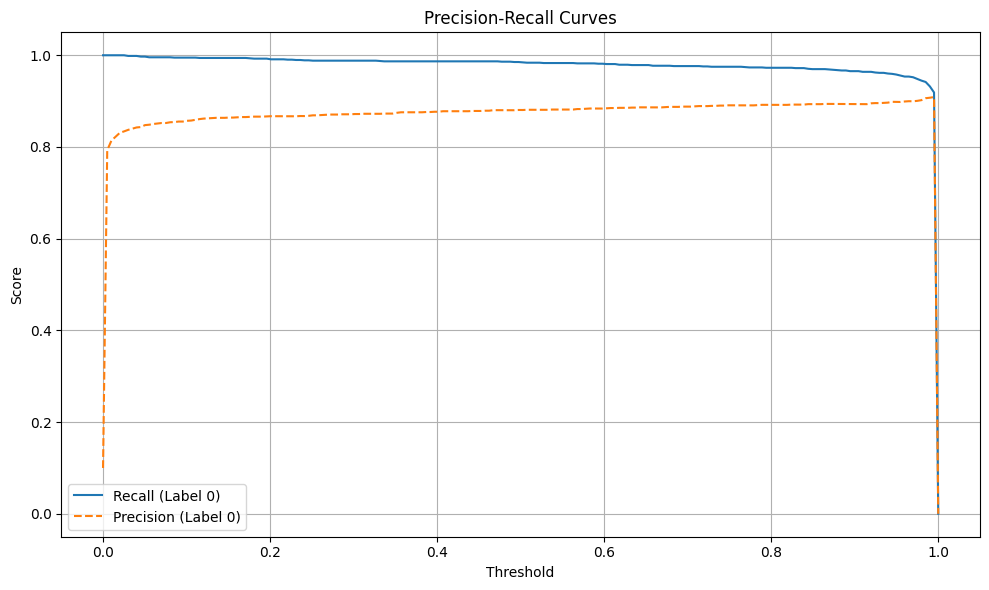

In [10]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_multi_label_precision_recall_curve(
    label_list,
    output_list,
    target_labels,
    num_thresholds=200,
    plot=True,
    separate_plots=True
):
    """
    Calculates and plots Precision and Recall curves as a function of probability 
    thresholds for multiple target labels.
    
    Args:
        label_list (list of torch.Tensor): Ground truth labels.
        output_list (list of torch.Tensor): Model outputs (logits).
        target_labels (list of int): List of classes to be analyzed.
        num_thresholds (int): Number of threshold points (determines precision).
        plot (bool): Whether to generate the plots.
        separate_plots (bool): Whether to plot each class in a separate figure.
    
    Returns:
        dict: A dictionary mapping each label to its corresponding 
              (thresholds, precisions, recalls).
    """
    
    labels_np = torch.cat(label_list).cpu().numpy()
    logits = torch.cat(output_list)
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()
    outputs_np = np.argmax(probabilities, axis=-1)

    thresholds = np.linspace(0.0, 1.0, num_thresholds)
    results = {}

    for target_label in target_labels:
        recalls = []
        precisions = []

        for threshold in thresholds:
            adjusted_labels = outputs_np.copy()
            for i in range(len(adjusted_labels)):
                if probabilities[i][target_label] >= threshold:
                    adjusted_labels[i] = target_label
                else:
                    adjusted_labels[i] = -1  

            binary_true = (labels_np == target_label).astype(int)
            binary_pred = (adjusted_labels == target_label).astype(int)

            cm = confusion_matrix(binary_true, binary_pred, labels=[0, 1])
            cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)
            cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

            precision = cm_precision[1, 1] if not np.isnan(cm_precision[1, 1]) else 0.0
            recall = cm_recall[1, 1] if not np.isnan(cm_recall[1, 1]) else 0.0

            precisions.append(precision)
            recalls.append(recall)

        results[target_label] = (thresholds, np.array(precisions), np.array(recalls))

    
    if plot:
        if separate_plots:
            num_labels = len(target_labels)
            ncols = 3
            nrows = int(np.ceil(num_labels / ncols))
            fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))

            axs = axs.flatten() if num_labels > 1 else [axs]

            for idx, target_label in enumerate(target_labels):
                t, p, r = results[target_label]
                ax = axs[idx]
                ax.plot(t, r, label=f'Recall (Label {target_label})')
                ax.plot(t, p, '--', label=f'Precision (Label {target_label})')
                ax.set_title(f"Precision-Recall Curve (Label {target_label})")
                ax.set_xlabel("Threshold")
                ax.set_ylabel("Score")
                ax.legend()
                ax.grid(True)

            
            for i in range(len(target_labels), len(axs)):
                fig.delaxes(axs[i])

            plt.tight_layout()
            plt.show()

        else:
            plt.figure(figsize=(10, 6))
            for target_label in target_labels:
                t, p, r = results[target_label]
                plt.plot(t, r, label=f'Recall (Label {target_label})')
                plt.plot(t, p, '--', label=f'Precision (Label {target_label})')
            plt.title("Precision-Recall Curves")
            plt.xlabel("Threshold")
            plt.ylabel("Score")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    return results


res = plot_multi_label_precision_recall_curve(label, output, target_labels=[0], separate_plots=False)

Accuracy: 0.9847
F1 Score: 0.9851
Recall: 0.9847


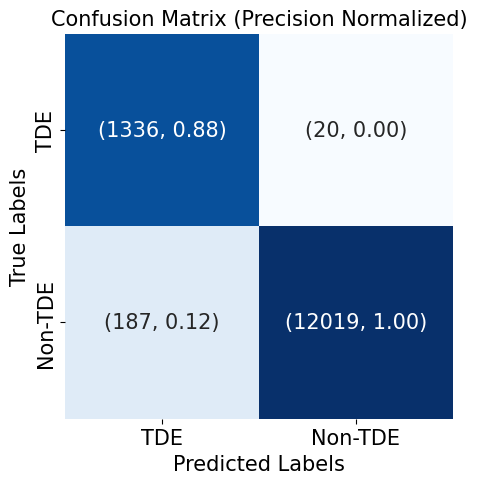

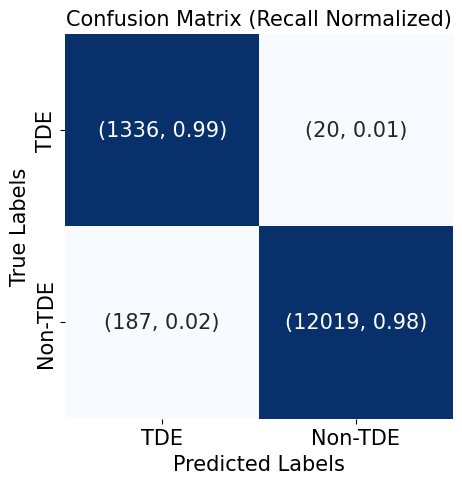

In [3]:
## import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix




labels_np_merged = labels_np
outputs_np_merged = outputs_np

labels_display = ['TDE', 'Not TDE']

# Precision
accuracy = accuracy_score(labels_np_merged, outputs_np_merged)
print(f"Accuracy: {accuracy:.4f}")

# F1
f1 = f1_score(labels_np_merged, outputs_np_merged, average='weighted')  # 可以选择 'micro', 'macro', 'weighted'
print(f"F1 Score: {f1:.4f}")

# Recall
recall = recall_score(labels_np_merged, outputs_np_merged, average='weighted')
print(f"Recall: {recall:.4f}")


cm = confusion_matrix(labels_np_merged, outputs_np_merged)


cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)

cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5, 5))

labels_display = ['TDE', 'Non-TDE']



plt.subplot(1, 1, 1)
annot_text = [[f"({cm[i, j]}, {cm_precision[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_precision, annot=annot_text, fmt="", cmap="Blues",
            xticklabels=labels_display, yticklabels=labels_display, cbar=False,annot_kws={"size": 15})
plt.xlabel('Predicted Labels',fontsize=15)
plt.ylabel('True Labels',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Confusion Matrix (Precision Normalized)',fontsize=15)
plt.savefig('model_another_s11-3-pre.png',bbox_inches='tight', dpi=300)
plt.show()



plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
annot_text = [[f"({cm[i, j]}, {cm_recall[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_recall, annot=annot_text, fmt="", cmap="Blues",
            xticklabels=labels_display, yticklabels=labels_display, cbar=False,annot_kws={"size": 15} )
plt.xlabel('Predicted Labels',fontsize=15)
plt.ylabel('True Labels',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Confusion Matrix (Recall Normalized)',fontsize=15)

#plt.tight_layout()
plt.savefig('model_another_s11-3-rec.png',bbox_inches='tight', dpi=300)
plt.show()
